[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation and Method Comparison

**Inputs.** The newest finished run of each method and seed under `outputs/optim/`, the baseline radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.

No GPU is needed and nothing is re-traced. Every table and figure is built by `src/evaluation/run.py`, the same code
`task evaluate` runs; this notebook only presents them.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.run import evaluate

# evaluate() seeds, sets the figure defaults and saves every table and figure itself.
cfg = load_config(overrides=CONFIG_OVERRIDES)
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

Build every table and figure once. Run directories that did not finish writing are skipped with a `WARNING` line.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)

## 1. Evaluation Objective

This notebook compares search methods for **multi-band antenna tilt coordination**: one absolute tilt per cell-band
pair, chosen to

* reduce coverage holes,
* reduce co-band coverage overlap and the number of overlapping neighbours,
* reduce weak coverage,
* raise the signal and interference levels where coverage exists,
* serve more UEs within the cells' PRB capacity,
* keep the load off any one cell and spread it evenly across them,

at a reasonable number of expensive ray-tracing evaluations. The ten KPIs are reported side by side and
weighed equally. None is ranked above another, and each is reported over all bands and per band. The single
number a search maximises is the objective $J$ of [ADR 0003](../docs/adr/0003-contraharmonic-objective-and-kpi-set.md), which is reported beside the KPIs, not in
place of them.

$J$ and the KPIs are both **tile-uniform**: nothing is weighted by demand. Where the traffic stands is still
reported, in section 10.2, but nothing optimises it.

Peak PRB utilisation is not among the KPIs. It is bounded by the 0.8 admission ceiling by construction, so it is
kept as the check that the serving rule held, in section 12, and not scored.

## 2. Methods Under Evaluation

| Method | Key | Type | Description |
|---|---|---|---|
| Current configuration | `incumbent` | Reference | The committed tilts, evaluation 0 of every run |
| Random search | `random` | Baseline | Scrambled Sobol samples over the tilt box; its first `n_init` points are TuRBO's initial design (`configs/optim/method/random.yaml`) |
| Rule-based sweep | `rule` | Baseline | Operator heuristic: one shared tilt per band, coordinate descent over a grid of values (`configs/optim/method/rule.yaml`) |
| TuRBO | `turbo` | Proposed | TuRBO-1 trust-region Bayesian optimisation on $J$ (`configs/optim/method/turbo.yaml`, ADR 0002 and ADR 0003) |

Random search and TuRBO share a seed and an evaluation budget, so they differ only in where they look. The rule-based
sweep is not budget-matched. There is no plain-random arm apart from Sobol, and the Multi-Agent Reinforcement
Learning arm is not implemented.

## 3. Experimental Setup

### 3.1 Tilt search space

For each cell-band pair $(i,b)$ the decision variable is the absolute tilt $\theta_{i,b}$, continuous within its bounds:

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

No tilt step and no maximum change from the current tilt $\theta^{(0)}$ are imposed; how far antennas moved is
reported in Section 13, not constrained.

### 3.2 Network, search space and budget

UE counts are over every UE, in the search and here alike (`src/evaluation/__init__.py`).

In [4]:
display(results["experiment_setup"])

,Parameter,Setting
0,Scenario,scn_7d938e15f9ac4618
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Decision variables (cell-band tilts),36
4,Evaluation area [m],6200 x 6520
5,Grid resolution [m],20
6,Grid tiles,101060
7,UE reports,10087
8,Measurement intervals,672
9,Tilt bounds [°],0 to 15


## 4. Evaluation KPIs

Notation: $R_{i,b}(g)$ is the RSRP of cell $i$ on band $b$ at tile $g \in G$, and $R_s(g) = \max_{(i,b)} R_{i,b}(g)$ is
the strongest layer. The thresholds $T_{\text{hole}}$, $T_{\text{weak}}$ and $\Delta_{\text{overlap}}$ are
`kpi.hole_dbm`, `kpi.weak_dbm` and `kpi.overlap_margin_db` in `configs/kpi.yaml`; their values are in the setup table
above. The implementations are in `src/kpi/`. Every one of the ten is also reported **per frequency layer**, by giving
the same function one band's slice of the radio map (section 11).

### 4.1 Coverage hole rate (minimise)

$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[R_s(g)\le T_{\text{hole}}\right]
$$

A tile with no ray-traced path counts as a hole.

### 4.2 Co-band overlap rate (minimise)

Overlap is **co-band**: within band $b$, the strongest transmitter serves, and each other transmitter $j$ on that band
is an overlapping neighbour when

$$
R_{j,b}(g) > T_{\text{hole}} \quad\text{and}\quad R_{j,b}(g) \ge \max_i R_{i,b}(g) - \Delta_{\text{overlap}}.
$$

$N_{\text{ov}}(g)$ is that count summed over bands, and $\mathrm{OverlapRate} = |\{g : N_{\text{ov}}(g) > 0\}| / |G|$.

### 4.3 Overlap neighbours per covered tile (minimise)

$$
\mathrm{OverlapNeighborMean} = \frac{1}{|G_{\text{covered}}|}\sum_{g\in G_{\text{covered}}} N_{\text{ov}}(g),
\qquad G_{\text{covered}} = \{g : R_s(g) > T_{\text{hole}}\}.
$$

The severity behind 4.2's incidence: it separates one competing neighbour from a pile-up of many.

### 4.4 Weak coverage rate (minimise)

$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[T_{\text{hole}} < R_s(g) \le T_{\text{weak}}\right]
$$

### 4.5 RSRP percentiles, $\mathrm{RSRP}_{p05}$ and $\mathrm{RSRP}_{p50}$ (maximise)

The 5th percentile and the median of $R_s(g)$ over $G_{\text{covered}}$. The 5% point is the cell-edge measure of
3GPP TR 36.814 Annex A.2.1.4. Both are **conditional on coverage**, so a configuration can raise them by covering
less: read them beside the hole rate, never alone.

### 4.6 SINR percentiles, $\mathrm{SINR}_{p05}$ and $\mathrm{SINR}_{p50}$ (maximise)

The same two points of the solver's SINR at the layer $R_s(g)$ names, over the same tiles, so 4.5 and 4.6 describe the
same cell-band at every tile. The SINR is the solver's own: it assumes every co-band transmitter is fully loaded, and
is not recomputed against the PRB load the serving rule produces.

### 4.7 Served UE rate (maximise)

The share of UE reports admitted to a cell-band above $T_{\text{hole}}$ under the serving rule and the PRB limits of
`src/kpi/capacity.py`. The capacity settings are placeholders, so read its direction rather than its level. A UE on a
hole and a UE blocked everywhere both count as not served.

### 4.8 Cell load imbalance (minimise)

The coefficient of variation of cell-band utilisation. Each cell-band's utilisation is averaged over every interval
(idle ones as zero), and the population standard deviation of those averages is divided by their mean. It is
scale-free: it does not move when the whole network gets busier, only when the traffic sits unevenly, which is what a
tilt change can fix. Zero means every cell-band carries the same share of its limit.

### 4.9 Objective $J$ (maximise)

$$
J = \frac{1}{|G|}\sum_{g\in G} \frac{\sum_b u_b(g)^2}{\sum_b u_b(g)},
\qquad u_b(g) = \lambda_{b}(g)\, e^{1 - \lambda_{b}(g)}\, s_{b}(g),
\qquad \lambda_b(g) = 1 + N_{\text{ov},b}(g),
\qquad s_b(g) = \mathrm{clip}\!\left(\frac{R_{b,\max}(g) - T_{\text{hole}}}{T_{\text{weak}} - T_{\text{hole}}},\, 0,\, 1\right)
$$

A tile no band covers scores 0.

**Each band is scored on its own.** $N_{\text{ov},b}$ is the 4.2 neighbour count on band $b$ alone, so
$\lambda_b$ counts the cells contending to serve the tile on that band, and $\lambda_b = 0$ where the band does not
clear $T_{\text{hole}}$. $\lambda e^{1-\lambda}$ is worth exactly 1 at $\lambda = 1$, 0.736 at 2, 0.406 at 3 and 0
at 0, so a band pays for one dominant server. $s_b$ then scales that by how far the band's strongest cell sits
between $T_{\text{hole}}$ and $T_{\text{weak}}$. A server at $-90$ dBm or better keeps all of it, one just out of a
hole keeps almost none, and power beyond $-90$ dBm buys nothing.

**The tile takes the contraharmonic mean of its bands' scores.** Each band is weighted by its own score, so the tile
lies between the plain mean and its best band. A crowded or marginal second layer lowers the tile: a clean band at
full strength beside a band with one neighbour scores 0.888, not 1. There is no band selection, and
`kpi.capacity.band_preference` is not read.

**The cost is monotonicity.** Removing a band raises the tile's score whenever that band scores below the tile, so a
tilt can gain $J$ by darkening a weak layer. Section 17 and the threats table say how much of the grid that touches.

$J \in [0, 1]$ and is **maximised**. It reaches 1 only if every covered band on every tile has one serving cell at or
above $T_{\text{weak}}$. It has no free parameters: it reads `kpi.hole_dbm`, `kpi.weak_dbm` and
`kpi.overlap_margin_db`, all of which the KPIs above already use. See [ADR 0003](../docs/adr/0003-contraharmonic-objective-and-kpi-set.md).


## 5. Result Loading and Validation

`evaluate` loaded the newest finished run of each method and seed; unfinished run directories were skipped above. Runs are compared only if they share the scenario, grid,
solver settings, bands and KPI definition, and only if each was scored by the objective this code
implements - `kpi.objective_version`, checked against the running config as well as run to run, because a
uniformly stale set agrees with itself. Otherwise `evaluate` raises. The recorded KPIs are then recomputed from
each archived radio map: any visible gap means the archived map is not the map that was scored.

In [5]:
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")
display(checks)
reproducibility = results["kpi_reproducibility"]
print(f"Largest recorded-vs-recomputed gap: {reproducibility['Absolute gap'].max():.2e}")

24 of 24 comparability checks hold


,Check,Holds,Offending runs
0,every run optimized the baseline's scenario,True,
1,grid n_rows matches the baseline,True,
2,grid n_cols matches the baseline,True,
3,grid tile_size_m matches the baseline,True,
4,grid origin_x matches the baseline,True,
5,grid origin_y matches the baseline,True,
6,grid ue_height_m matches the baseline,True,
7,solver samples_per_tx matches the baseline,True,
8,solver max_depth matches the baseline,True,
9,solver los matches the baseline,True,


Largest recorded-vs-recomputed gap: 3.48e-06


**Observations.** All 24 comparability checks hold. Every run carries `kpi.objective_version = 3`, the objective this code implements, and that check runs against the running config as well as run to run, because a uniformly stale set agrees with itself. The KPIs recomputed from each archived radio map match the recorded ones to at most 3.5e-06 (the rule sweep's median SINR, in dB), and the objective itself matches to under 2e-10. The winner's map is re-traced after the search, and GPU ray tracing is not bit-reproducible, so that is the size of the solver's own noise, not a bookkeeping error. The three runs measure the same thing, so their differences come from tilt alone. One search seed (42) per method was found.

## 6. Final KPI Comparison

### 6.1 Best configuration per method

Each method's winner, averaged over seeds, against the current configuration. With one seed per method the spread and
interval columns are empty.

In [6]:
display(results["kpi_scoreboard"])
display(results["method_cost"])

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1125,0.1083,NaN,NaN,NaN,-0.0042,better
1,Random search,Co-band overlap rate,minimise,1,0.3164,0.3254,NaN,NaN,NaN,0.0090,worse
2,Random search,Overlap neighbours per covered tile,minimise,1,0.9625,1.0303,NaN,NaN,NaN,0.0678,worse
3,Random search,Weak coverage rate,minimise,1,0.3069,0.2864,NaN,NaN,NaN,-0.0206,better
4,Random search,"Cell-edge RSRP, p05 [dBm]",maximise,1,-108.5644,-107.9820,NaN,NaN,NaN,0.5824,better
5,Random search,"Median RSRP, p50 [dBm]",maximise,1,-84.1068,-82.7177,NaN,NaN,NaN,1.3892,better
6,Random search,"Cell-edge SINR, p05 [dB]",maximise,1,-5.8729,-5.5418,NaN,NaN,NaN,0.3311,better
7,Random search,"Median SINR, p50 [dB]",maximise,1,8.4932,9.2144,NaN,NaN,NaN,0.7211,better
8,Random search,Served UE rate,maximise,1,0.5265,0.5882,NaN,NaN,NaN,0.0617,better
9,Random search,Cell load imbalance (CoV),minimise,1,0.9098,1.0092,NaN,NaN,NaN,0.0994,worse


,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,2026-09-22_08-09-20,145,7,6.6332,10.3287,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,1.0092,0.6911,8,3
1,Rule-based sweep,42,2026-09-22_08-19-40,111,21,4.5005,7.2360,0.1044,0.3181,1.1866,0.2535,-106.9675,-80.7966,-4.9663,9.9010,0.5988,0.9963,0.6963,8,3
2,TuRBO,42,2026-09-22_08-27-54,145,138,9.0447,17.1768,0.1079,0.3070,0.9918,0.2665,-107.4394,-81.7281,-4.9822,11.0255,0.5898,0.9746,0.7049,9,2


### 6.2 Improvement over the current configuration

$$
\Delta K = \pm\,\frac{K_{\text{optimised}} - K_{\text{initial}}}{|K_{\text{initial}}|}\times 100\,\%,
$$

signed so that a positive value is an improvement whichever direction the KPI runs.

,Method,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J
0,Random search,3.7650,-2.8397,-7.0449,6.6996,0.5365,1.6517,5.6372,8.4906,11.7115,-10.9290,3.9045
1,Rule-based sweep,7.1692,-0.5254,-23.2752,17.3937,1.4709,3.9357,15.4362,16.5756,13.7262,-9.5051,4.6838
2,TuRBO,4.0464,2.9679,-3.0357,13.1670,1.0362,2.8283,15.1653,29.8148,12.0128,-7.1193,5.9808


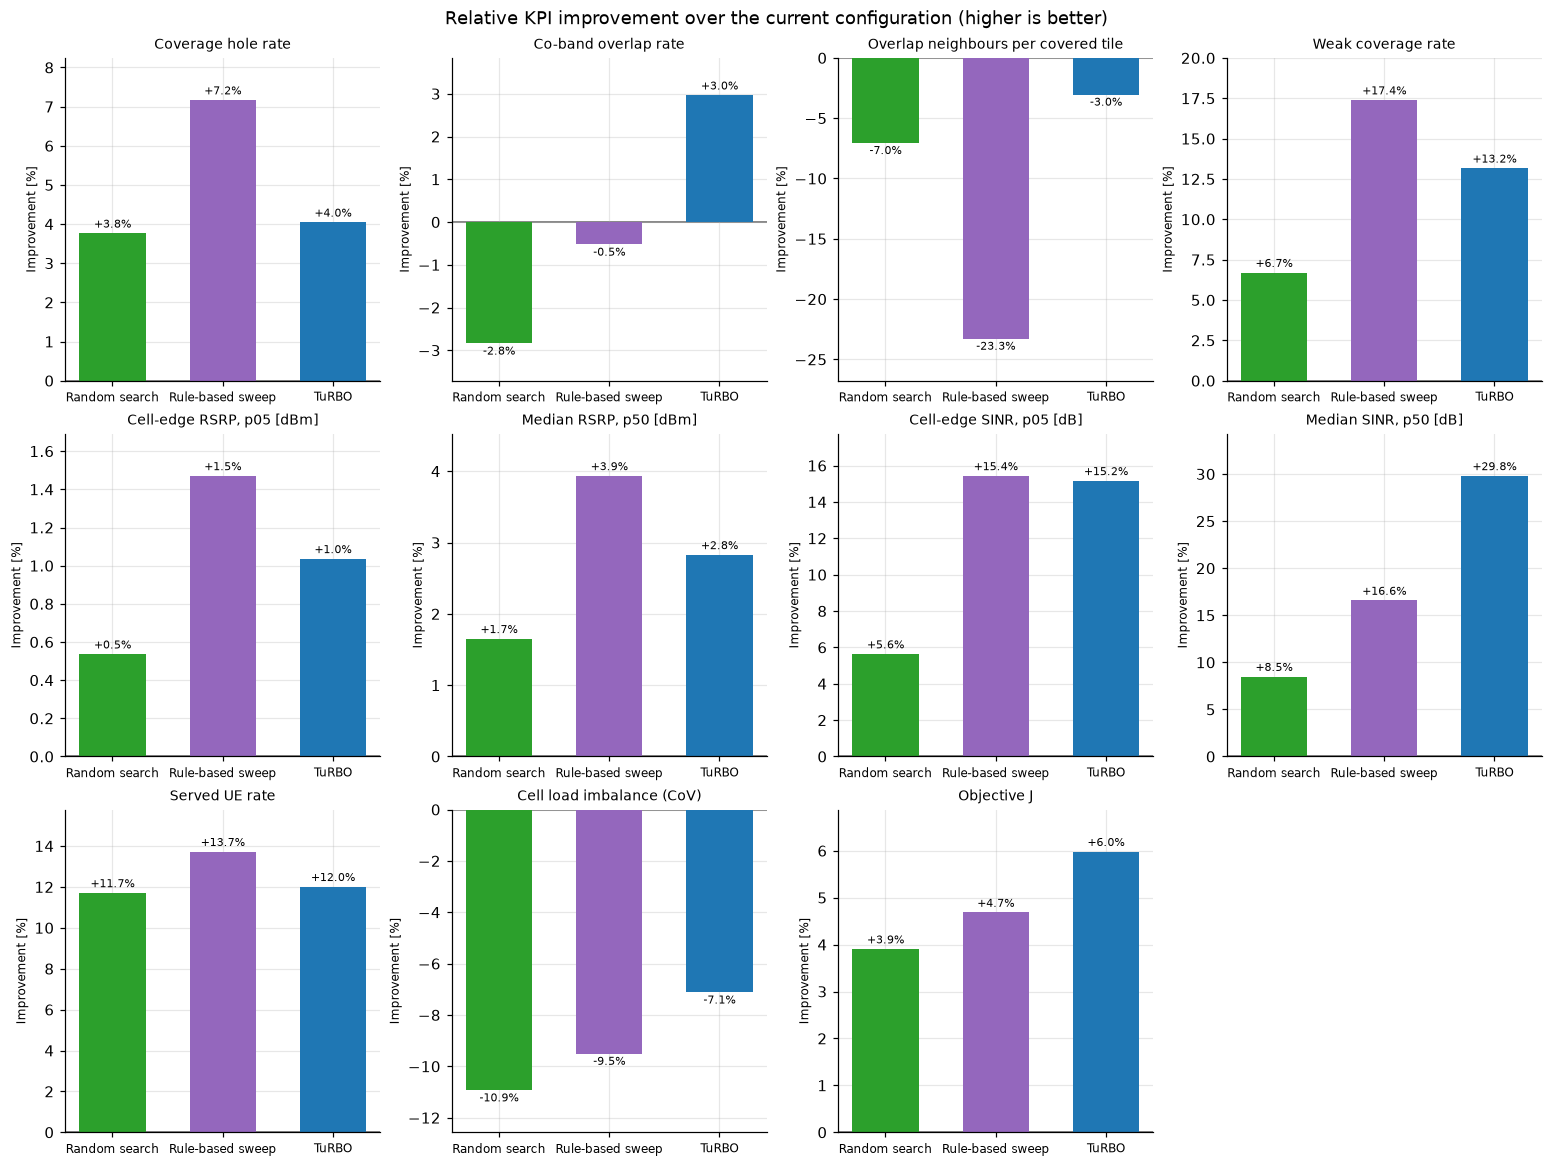

In [7]:
display(results["kpi_relative_improvement"])
display(results["kpi_improvement"])

**Observations.** TuRBO raises the objective most: **+5.98 % relative, 0.6651 to 0.7049**. The rule-based sweep gains +4.68 % and random search +3.90 %. Counting the ten KPIs and $J$, TuRBO is 9 better and 2 worse; both baselines are 8 and 3.

$J$ scores each band for one dominant cell at usable strength and takes the contraharmonic mean over the tile's bands (ADR 0003). It is bounded in $[0, 1]$, has no free parameters and reads no demand map.

**The objective and the KPI set agree about the winner.** TuRBO wins $J$, and the candidate with the best equal-weight rank score over the ten KPIs is also a TuRBO candidate, 0.0002 of $J$ below the one it picked. Over random search's 145 Sobol candidates, Spearman's rho between $J$ and that rank score is **0.918** (ADR 0003, Measured outcome).

**Head to head, the rule sweep takes 6 of the 10 KPIs and TuRBO 4.**
- **The sweep's six:** hole rate (0.1044 against 0.1079), weak rate (0.2535 against 0.2665), both RSRP percentiles, cell-edge SINR and the served rate (0.5988 against 0.5898).
- **TuRBO's four:** overlap rate, overlap neighbours per covered tile, median SINR and cell load imbalance.

**Only TuRBO lowers the co-band overlap rate** (0.3164 to 0.3070). It rises under random search (0.3254) and the sweep (0.3181). **Overlap neighbours per covered tile** rises under all three, least under TuRBO (0.9625 to 0.9918). These are the two KPIs $J$ tracks least well: rho 0.427 and 0.297 over the Sobol sample.

**Cell load imbalance worsens under all three**, least under TuRBO (0.9098 to 0.9746). Nothing in $J$ asks for even load.

## 7. Optimization Convergence

Best objective found so far against the number of evaluations, the current configuration being evaluation 0. The
band is the min–max over seeds and collapses to the line with one seed.

The second table asks whether the search mattered: each winner against the typical candidate its own search evaluated.

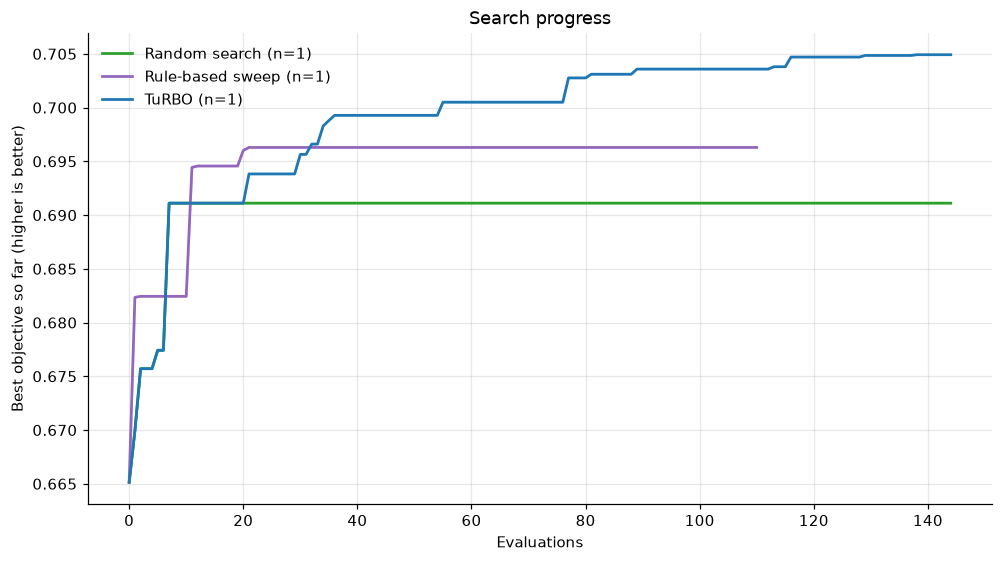

,Method,Seed,Current configuration,"Initial design, median objective","All candidates, median objective","All candidates, 90th percentile objective",Best objective found
0,Random search,42,0.6651,0.6701,0.6711,0.6819,0.6911
1,Rule-based sweep,42,0.6651,NaN,0.6917,0.6960,0.6963
2,TuRBO,42,0.6651,0.6701,0.6990,0.7040,0.7049


In [8]:
display(results["search_progress"])
display(results["winner_vs_candidates"])

**Observations.** TuRBO's median candidate (0.6990) scores above both baselines' best: the rule sweep's 0.6963 and random search's 0.6911. Its 90th percentile is 0.7040. The trust region spends its budget near good configurations.

Random search's candidates sit around their Sobol design median (0.6711), which is *above* the current configuration's 0.6651. So the committed per-band tilts are a slightly weak starting point rather than a strong one. Random search found its best at evaluation 7. The rule sweep's median candidate (0.6917) is high because it only moves whole bands around the current tilts, so it never visits a bad region.

TuRBO and random search share the same 16 Sobol points and diverge only once the model starts proposing. The shared design's median is 0.6701 for both, while TuRBO's all-candidate median is 0.6990 against random search's 0.6711.

## 8. Sample Efficiency

Best value reached after a fixed number of evaluations, averaged over seeds. Each KPI is its own running best, so the
rows of one budget need not come from one configuration. The last budget is the longest run; a budget past a run's
length is empty.

In [9]:
display(results["sample_efficiency"])

,KPI,Evaluations,Random search,Rule-based sweep,TuRBO
0,Objective J,10,0.6911,0.6824,0.6911
1,Objective J,25,0.6911,0.6963,0.6938
2,Objective J,50,0.6911,0.6963,0.6993
3,Objective J,100,0.6911,0.6963,0.7036
4,Objective J,145,0.6911,NaN,0.7049
5,Coverage hole rate,10,0.1083,0.1114,0.1083
6,Coverage hole rate,25,0.1083,0.1043,0.1076
7,Coverage hole rate,50,0.1082,0.1043,0.1071
8,Coverage hole rate,100,0.1082,0.1043,0.1066
9,Coverage hole rate,145,0.1082,NaN,0.1066


**Observations.** The rule sweep reaches its final 0.6963 within 25 evaluations (its best is evaluation 21), and at that budget it is ahead: TuRBO has 0.6938. TuRBO passes it at evaluation 32 and keeps improving, to 0.6993 by 50, 0.7036 by 100 and 0.7049 at 145, finding its best at evaluation 138. Random search reaches 0.6911 at evaluation 7 and never improves on it.

**The running-best overlap rate separates the methods.** TuRBO's candidates reach 0.2989 and the rule sweep's reach 0.3061, both below the incumbent's 0.3164, but no random-search candidate ever beats the incumbent.

## 9. Multi-Objective Trade-Offs and Pareto Fronts

Each point is one evaluated configuration. The stars mark each method's highest-$J$ configuration, the
cross marks the current configuration, and the dashed line joins the Pareto-efficient configurations over all methods:
those that no other configuration beats on both axes at once.

The served UE ratio takes the place of the template's band-priority axis, which is not used in this project.

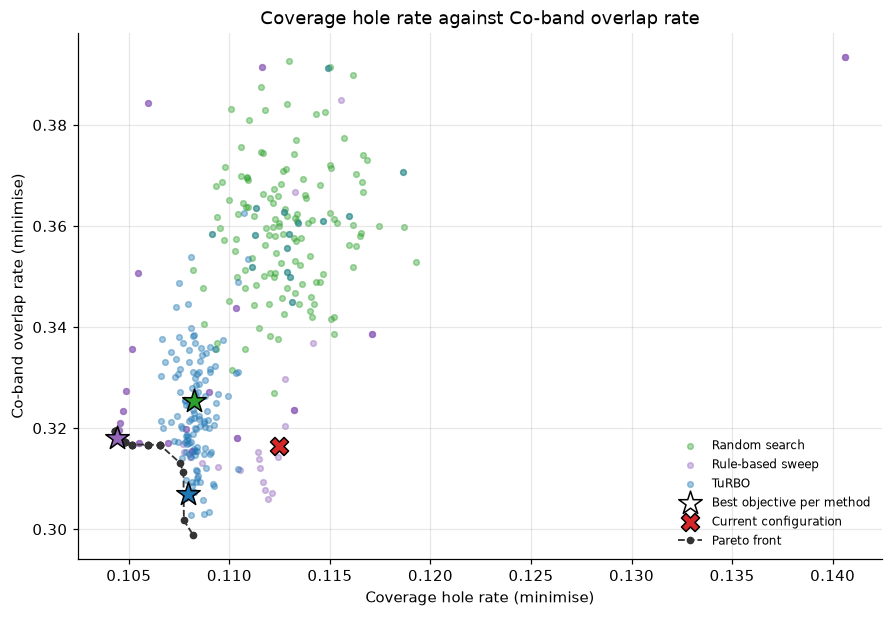

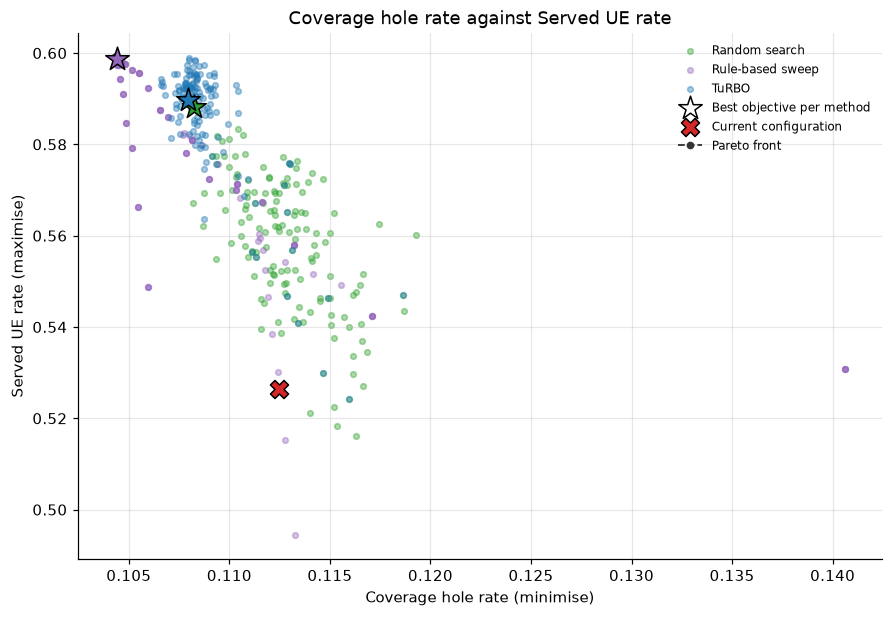

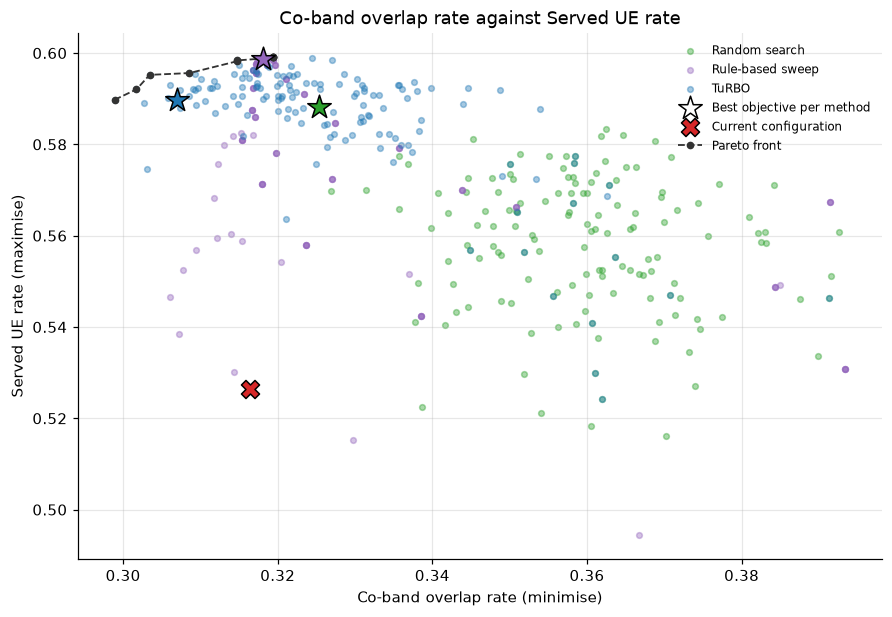

In [10]:
display(results["tradeoff_hole_rate_vs_overlap_rate"])
display(results["tradeoff_hole_rate_vs_served_rate"])
display(results["tradeoff_overlap_rate_vs_served_rate"])

**Observations.** Hole rate and overlap rate still conflict along the Pareto front. Splitting a clean strong tile costs 0.264, while a newly covered tile arrives near $T_{\text{hole}}$, where the strength factor is near zero, and is worth about 0.09 on this run. So **one newly crowded strong tile costs roughly three closed holes**.

TuRBO's pick is the only one below the current configuration's overlap rate of 0.3164: it sits at 0.3070, against the sweep's 0.3181 and random search's 0.3254.

Against the served rate, all three picks sit close together, between 0.588 and 0.599. The served rate is bounded by the 0.8 admission ceiling rather than by coverage, so it cannot be traded far in either direction.

## 10. Spatial Coverage Analysis

### 10.1 Change in best-server RSRP per method

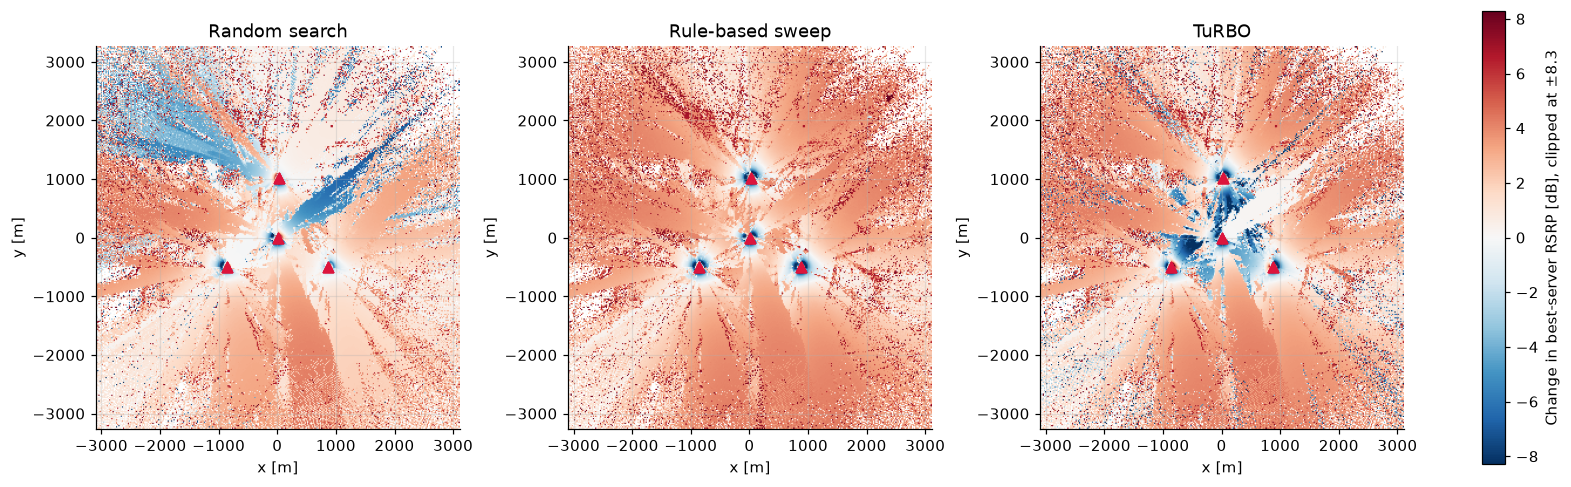

In [11]:
display(results["rsrp_change_maps"])

### 10.2 Before and after: the recommended configuration

The recommended configuration is the run with the highest objective over all methods. Both panels use the same scale
and the same coverage classes.

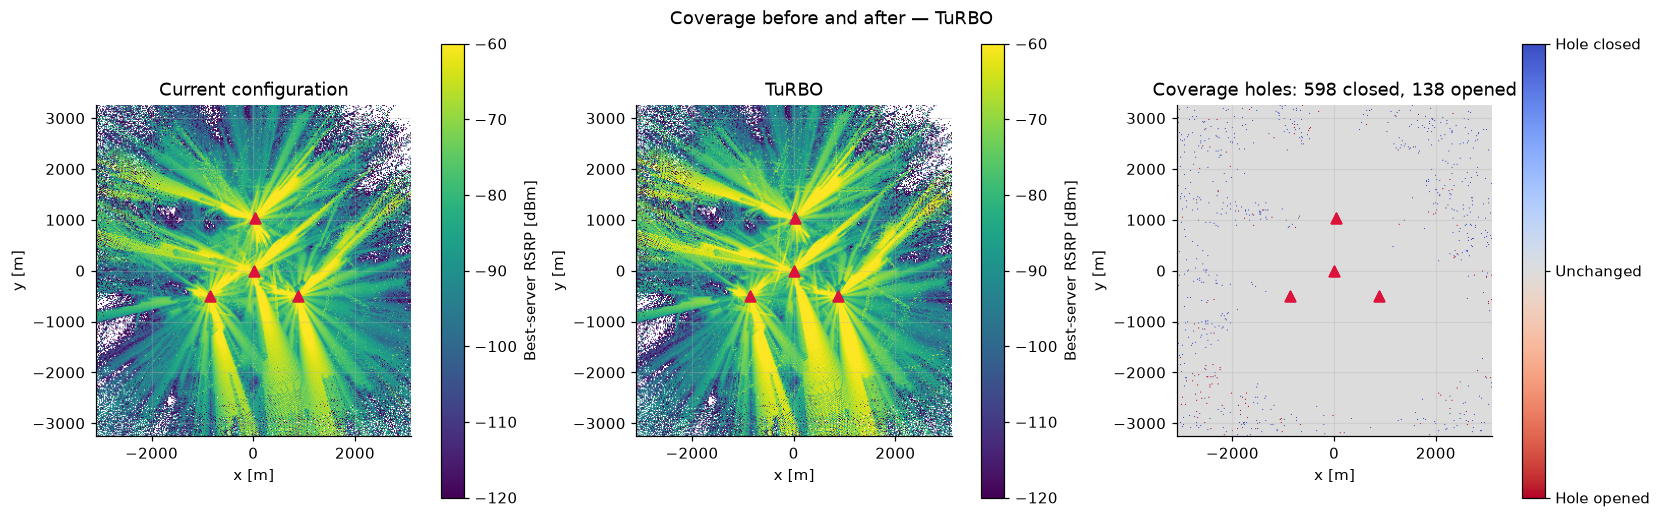

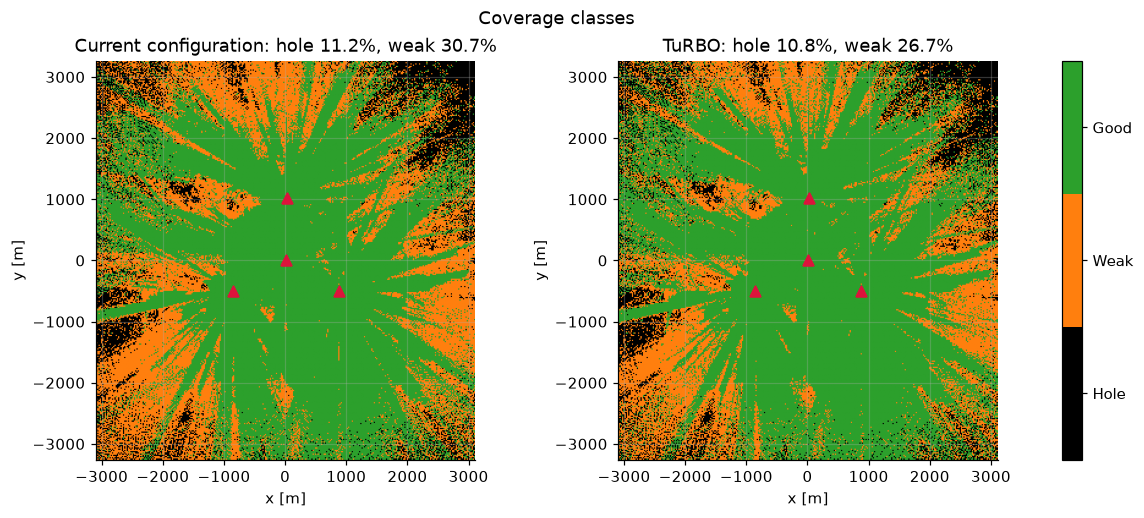

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1125,0.000,0.1083,0.0027,0.1044,0.0000,0.1079,0.0044
1,weak,0.3069,0.836,0.2864,0.7967,0.2535,0.7673,0.2665,0.7874
2,good,0.5806,0.164,0.6054,0.2006,0.6420,0.2327,0.6256,0.2082


In [12]:
display(results["coverage_before_after"])
display(results["coverage_class_maps"])
display(results["coverage_by_area_and_demand"])

### 10.3 Overlap neighbours

,Configuration,"Mean overlap neighbours, covered tiles","Mean overlap neighbours, all tiles",Share with 0 neighbours,Share with 1 neighbour,Share with 2 neighbours,Share with 3+ neighbours
0,Current configuration,0.9625,0.8543,0.6435,0.1127,0.0677,0.1761
1,Random search,1.0303,0.9188,0.6351,0.1252,0.0722,0.1675
2,Rule-based sweep,1.1866,1.0627,0.6449,0.1007,0.0734,0.1810
3,TuRBO,0.9918,0.8847,0.6558,0.1100,0.0745,0.1597


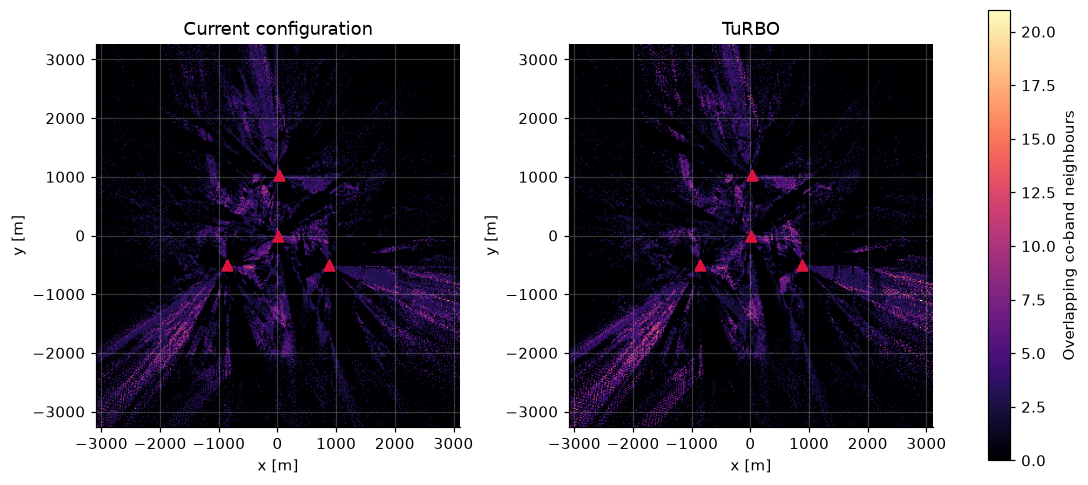

In [13]:
display(results["overlap_neighbour_summary"])
display(results["overlap_neighbour_maps"])

**Observations.** The recommended TuRBO configuration improves coverage by area on every class: holes 11.2 % to 10.8 %, weak 30.7 % to 26.7 %, good 58.1 % to 62.6 %. Weighted by where the served traffic stands, the share on weak tiles falls from 83.6 % to 78.7 %, and the share on good tiles rises from 16.4 % to 20.8 %. Meanwhile 0.4 % of demand lands on hole tiles, where none did before. Nothing in the objective reads that demand view, so it is a check on the result rather than a reflection of it, and here the check finds something.

**TuRBO is the only method that makes more tiles clean.** The share of covered tiles with **no** overlapping neighbour rises from 64.4 % to 65.6 %, and the share with **three or more** falls from 17.6 % to 16.0 %, the best of the three methods. The mean over covered tiles still rises slightly, from 0.963 to 0.992.

The rule sweep, which has no per-cell freedom, raises the mean further, to 1.187, and thickens the pile-ups: 17.6 % to 18.1 %.

## 11. Frequency-Layer Analysis

Per band: the area the band covers above the hole threshold and its mean RSRP there, the area the serving rule assigns
to it, and the share of UE reports actually admitted on it after PRB limits, with their median SINR. The band preference
of the serving rule is `kpi.capacity.band_preference`.

Then every KPI of section 4 again, per layer. The `all` row is the whole radio map and equals the scoreboard above; a
band row is the same function given that band's layers, so nothing is redefined. The per-band served rates are shares
of *all* reports and so sum to the `all` row; the rates over tiles do not sum to anything, because a tile can be a hole
on two bands at once. There is no per-band objective: $J$ scores a network, and one layer of a multi-band network is
not a network.

,Configuration,Band,Share of area covered by the band,Mean band RSRP where covered [dBm],Share of area served on the band,Share of UE reports served on the band,"Served SINR on the band, median [dB]"
0,Current configuration,2600 MHz,0.7116,-97.1547,0.7116,0.3408,3.4679
1,Current configuration,1800 MHz,0.7650,-91.4508,0.0584,0.1050,5.1757
2,Current configuration,700 MHz,0.8619,-84.2119,0.1176,0.0807,13.3089
3,Random search,2600 MHz,0.7413,-91.9058,0.7413,0.4506,7.1671
4,Random search,1800 MHz,0.7740,-88.6395,0.0408,0.0715,4.7737
5,Random search,700 MHz,0.8641,-83.3514,0.1096,0.0661,12.0027
6,Rule-based sweep,2600 MHz,0.7486,-90.6111,0.7486,0.4629,7.3262
7,Rule-based sweep,1800 MHz,0.7827,-87.2716,0.0413,0.0638,4.8727
8,Rule-based sweep,700 MHz,0.8675,-81.7725,0.1057,0.0721,13.2202
9,TuRBO,2600 MHz,0.7454,-91.2246,0.7454,0.4457,6.5673


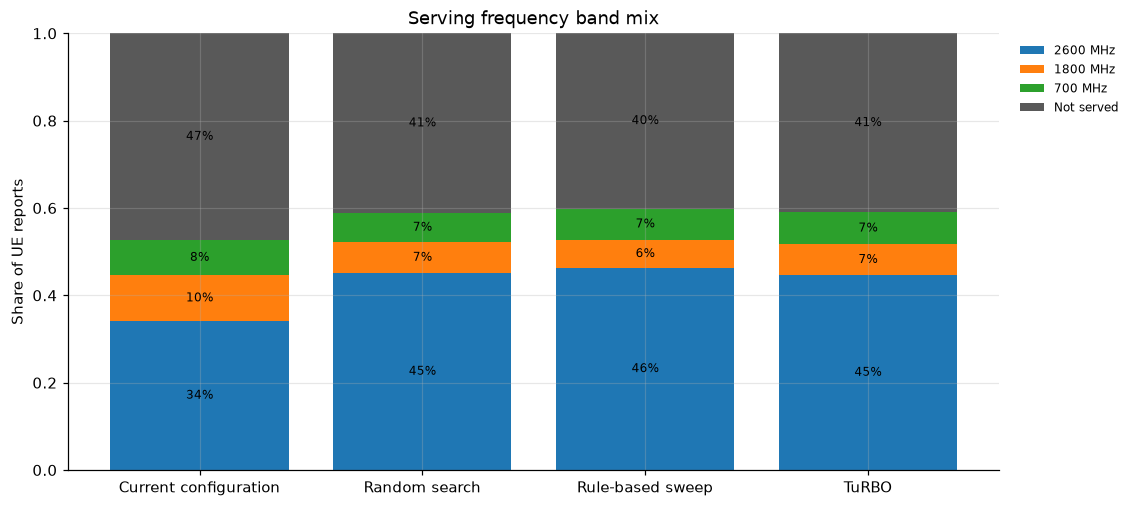

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
2,Rule-based sweep,10087.0,0.4012,0.3564,7.8600,39.2656,0.4629,0.0638,0.0721
3,TuRBO,10087.0,0.4102,0.2414,7.4675,40.8734,0.4457,0.0712,0.0729


,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,prb_utilisation_max,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
5,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835
6,Random search,1800 MHz,0.2260,0.1952,0.3442,0.3546,-111.7681,-88.4004,-11.0177,6.1660,0.0715,0.7997,0.9939
7,Random search,700 MHz,0.1359,0.2422,0.4142,0.2831,-108.2549,-82.9697,-5.1376,8.6310,0.0661,0.7988,1.1114
8,Rule-based sweep,All bands,0.1044,0.3181,1.1866,0.2535,-106.9675,-80.7966,-4.9663,9.9010,0.5988,0.7999,0.9963
9,Rule-based sweep,2600 MHz,0.2514,0.1951,0.4288,0.3821,-113.3120,-90.4014,-15.5123,3.5452,0.4629,0.7999,0.5643


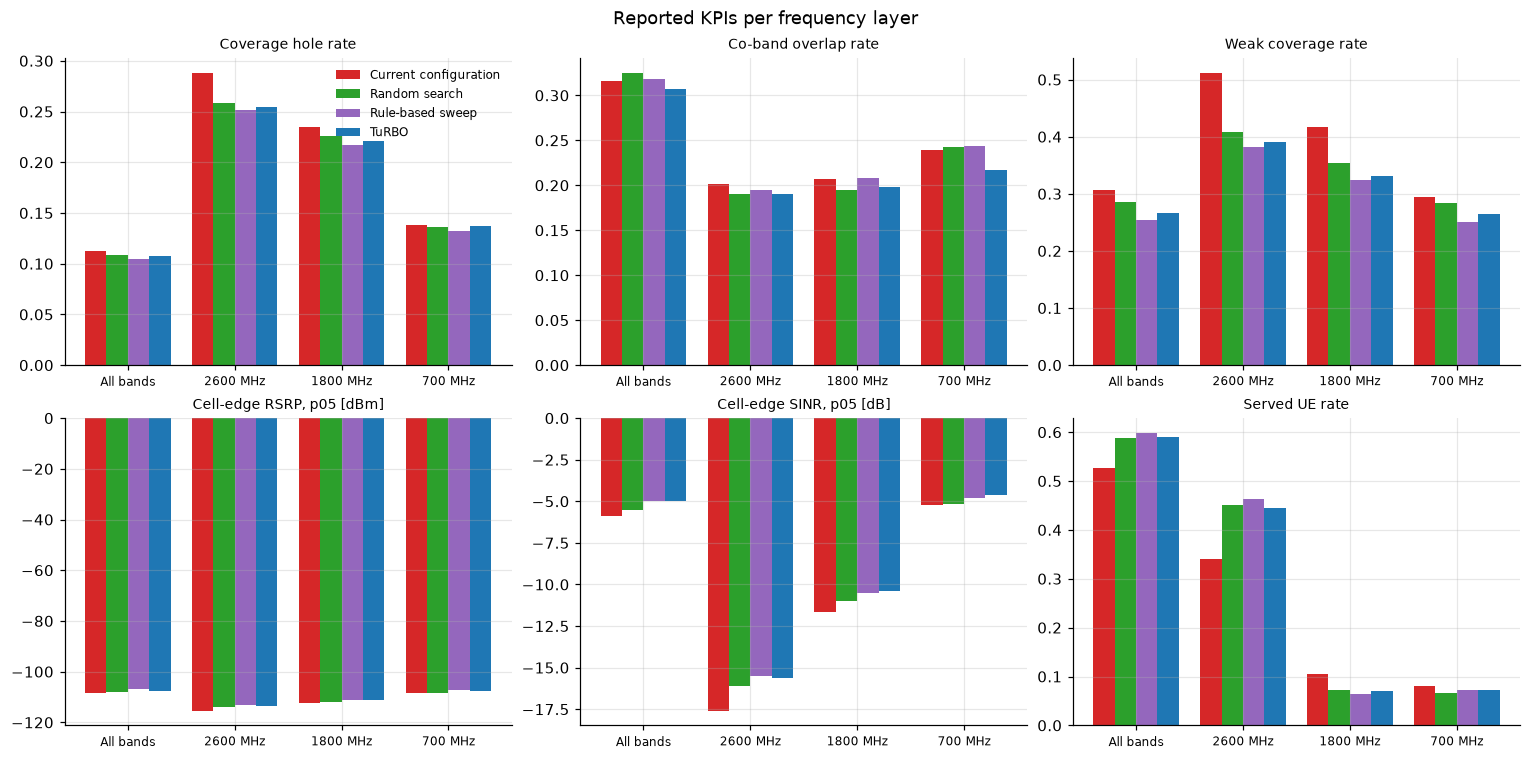

In [14]:
display(results["band_layer_summary"])
display(results["serving_band_mix"])
display(results["ue_service_summary"])
display(results["band_kpis"])
display(results["band_kpi_panels"])

**Observations.** The per-band rows are the point of a multi-band study, and they say something the whole-network row cannot: **no single layer covers the area**. Alone, 2600 MHz leaves 28.8 % of tiles as holes, 1800 MHz 23.5 % and 700 MHz 13.8 %, against 11.2 % for the union. The layers are complementary, not redundant, and that is the premise the project rests on.

**Every covered layer counts in $J$, and the per-band overlap rows show it.**
- **2600 MHz** falls under every method: 0.2010 to 0.1899 under TuRBO, 0.1908 under random search and 0.1951 under the sweep.
- **1800 MHz** falls under TuRBO (0.1976) and random search (0.1952), and rises slightly under the sweep (0.2077).
- **700 MHz** falls only under TuRBO, 0.2396 to 0.2171, and rises under both baselines.

TuRBO is the only method that improves all three bands and the band-collapsed rate.

Per-band hole rates improve on every layer under every method. Under TuRBO: 2600 MHz 0.288 to 0.255, 1800 MHz 0.235 to 0.221, 700 MHz 0.138 to 0.137.

**All three methods push served traffic onto the preferred 2600 MHz layer.** Its share of UE reports rises from 34.1 % to 44.6 % under TuRBO, 45.1 % under random search and 46.3 % under the sweep, while 1800 MHz falls from 10.5 % to between 6.4 % and 7.1 %. Service quality rises under all three. Under TuRBO, median PRBs per served UE fall from 53.2 to 40.9, median served SINR rises from 5.1 to 7.5 dB, and the 10th-percentile served SINR rises from -0.38 to +0.24 dB. The sweep does best on all three (39.3 PRBs, 7.9 dB and +0.36 dB).

The busiest cell-bands in every configuration peak at about 0.8 of their PRB limit, the admission ceiling. That figure is the check that the serving rule held, which is why it is not a KPI.

## 12. Cell Load and PRB Usage

Peak PRB utilisation and the load-imbalance KPI are reductions of one series: the PRBs each cell-band carried in each
15-minute interval, as a share of its own limit. The heatmap is that series; the table beside it is the per-cell-band
summary the utilisation figure is drawn from.

The serving rule refuses any admission that would carry a cell-band past `kpi.capacity.max_admission_utilisation`, so
no cell can appear above the ceiling. A cell *at* the ceiling is one that turned traffic away, and that traffic shows
up in the served rate, not here.

Peak PRB utilisation is **not** among the reported KPIs (ADR 0003), because it is bounded by the ceiling by
construction. It is printed here as the check that the admission rule held: anything above 0.8 is a fault. It is not
scored.

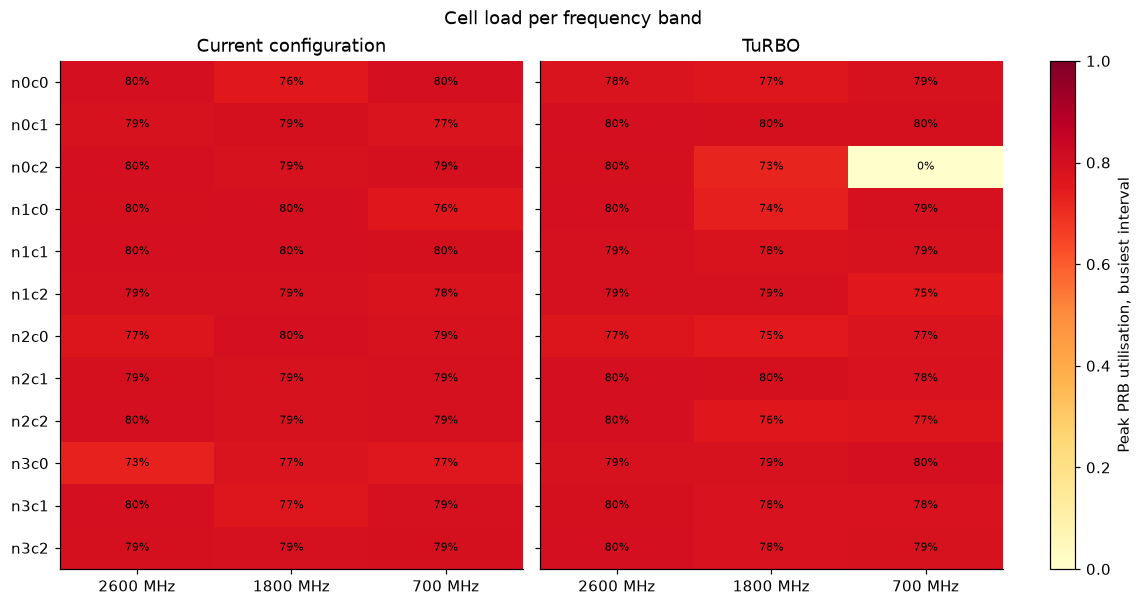

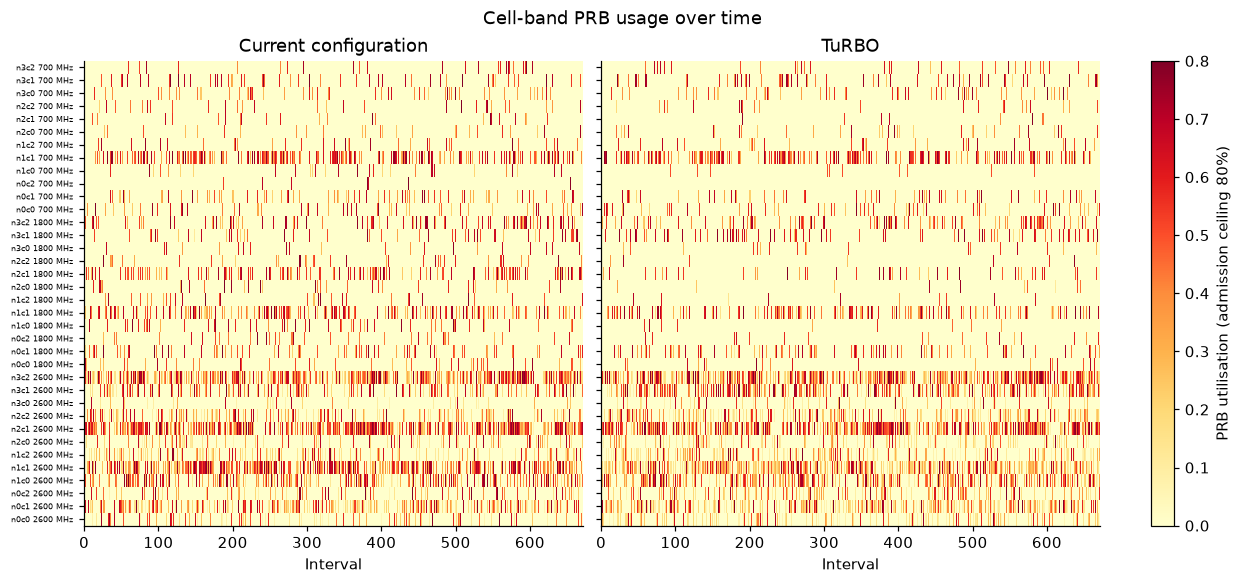

,Cell,Band,Served reports,Mean PRB load,Peak PRB load,PRB limit,Median SINR [dB],Peak PRB utilisation,Configuration
0,n0c0,2600 MHz,123,12.6004,172.1595,216.0,3.9552,0.7970,Current configuration
1,n0c1,2600 MHz,389,31.6248,170.0246,216.0,8.1041,0.7872,Current configuration
2,n0c2,2600 MHz,103,13.0561,172.7687,216.0,2.1295,0.7999,Current configuration
3,n1c0,2600 MHz,276,37.9955,171.7453,216.0,1.2829,0.7951,Current configuration
4,n1c1,2600 MHz,538,63.5284,172.7813,216.0,2.7273,0.7999,Current configuration
...,...,...,...,...,...,...,...,...,...
31,n2c1,700 MHz,11,0.4894,40.7338,52.0,11.3941,0.7833,TuRBO
32,n2c2,700 MHz,27,0.9700,40.0453,52.0,14.1322,0.7701,TuRBO
33,n3c0,700 MHz,67,2.1662,41.5423,52.0,16.1117,0.7989,TuRBO
34,n3c1,700 MHz,76,3.5047,40.6425,52.0,9.1681,0.7816,TuRBO


,Configuration,Cell,Band,Interval,PRB load,PRB utilisation
0,TuRBO,n2c2,2600 MHz,291,172.7969,0.8000
1,Current configuration,n1c1,2600 MHz,295,172.7813,0.7999
2,Current configuration,n0c2,2600 MHz,379,172.7687,0.7999
3,Current configuration,n2c2,2600 MHz,204,172.7200,0.7996
4,Current configuration,n2c0,1800 MHz,131,84.7339,0.7994
5,TuRBO,n3c2,2600 MHz,387,172.6471,0.7993
6,Current configuration,n0c0,700 MHz,409,41.5521,0.7991
7,TuRBO,n3c0,700 MHz,622,41.5423,0.7989
8,TuRBO,n2c1,2600 MHz,58,172.5538,0.7989
9,Current configuration,n1c1,1800 MHz,256,84.6485,0.7986


In [15]:
display(results["cell_band_utilisation"])
display(results["prb_usage_heatmaps"])
display(results["cell_band_load"])

# 48k rows is a series, not a table; show where it runs hottest.
usage = results["prb_usage_by_time"]
busiest = (
    usage.sort_values("PRB utilisation", ascending=False)
    .drop_duplicates(["Configuration", "Cell", "Band"])
    .head(10)
    .reset_index(drop=True)
)
display(busiest)

## 13. Tilt Configuration Analysis

$$
\Delta\theta_{i,b} = \theta^{*}_{i,b} - \theta^{(0)}_{i,b}
$$

for the recommended configuration. Negative is uptilt. The cell impact table is sorted by how much traffic each
cell-band gained or lost, so the cells to watch after rollout come first.

,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,2.2513,-9.7487,0.0,15.0
1,n0c0,1800 MHz,10.0,0.1473,-9.8527,0.0,15.0
2,n0c0,700 MHz,8.0,1.4286,-6.5714,0.0,15.0
3,n0c1,2600 MHz,12.0,4.9049,-7.0951,0.0,15.0
4,n0c1,1800 MHz,10.0,0.2987,-9.7013,0.0,15.0
5,n0c1,700 MHz,8.0,1.9416,-6.0584,0.0,15.0
6,n0c2,2600 MHz,12.0,6.5716,-5.4284,0.0,15.0
7,n0c2,1800 MHz,10.0,5.8291,-4.1709,0.0,15.0
8,n0c2,700 MHz,8.0,14.2853,6.2853,0.0,15.0
9,n1c0,2600 MHz,12.0,4.8892,-7.1108,0.0,15.0


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,6.4435,9.8527,-6.3713
1,2600 MHz,12,12,7.7016,11.8457,-7.7016
2,700 MHz,12,12,5.3517,7.2315,-2.7935


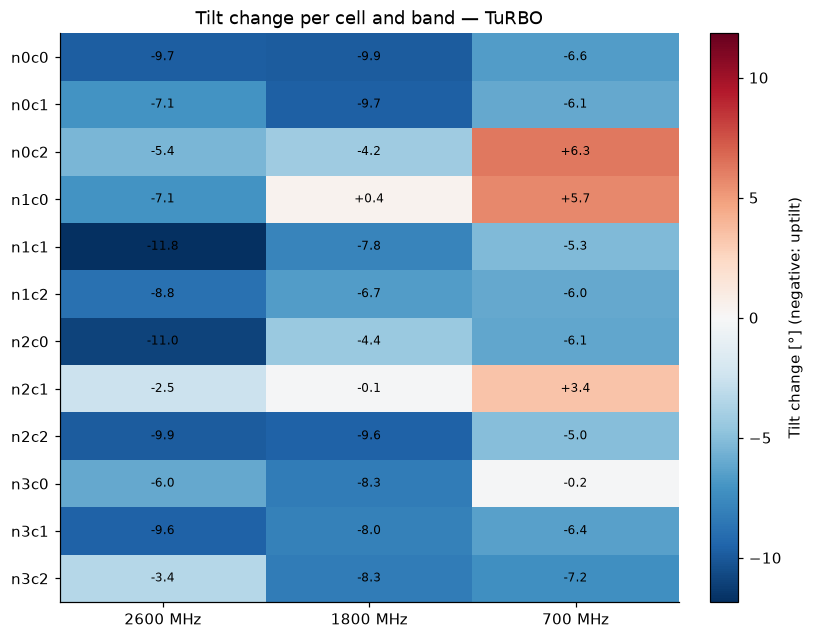

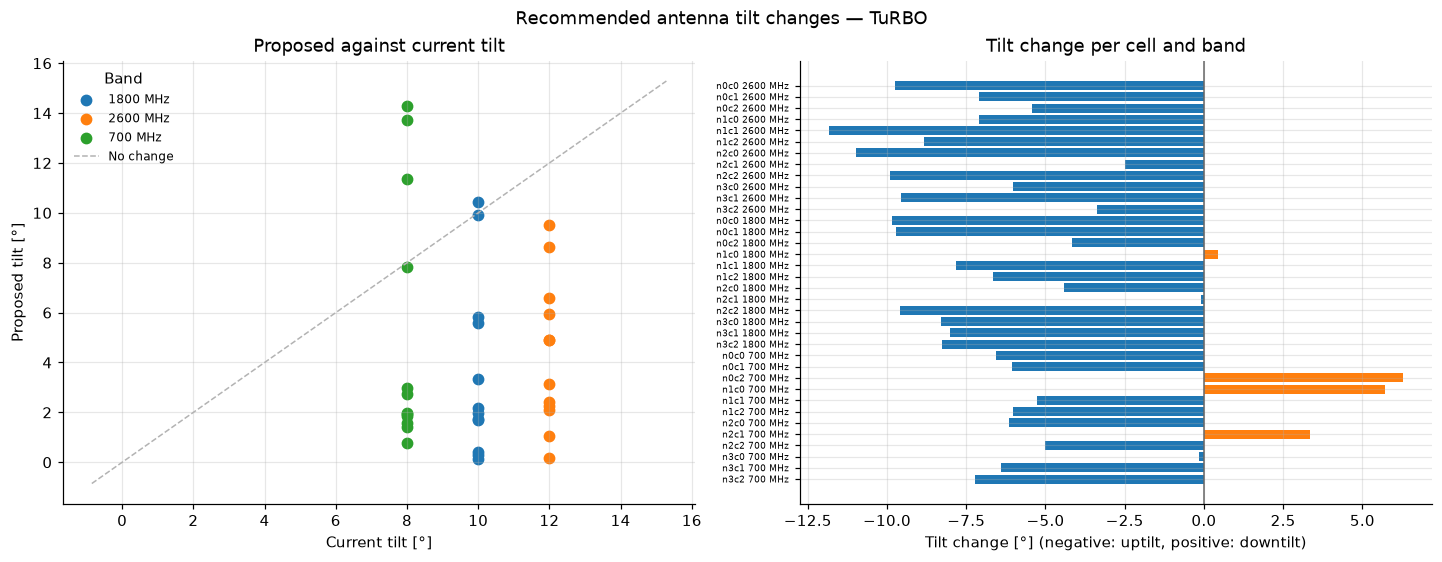

,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n1,n1c1,165.0,2600 MHz,12.0,0.1543,-11.8457,538,0.7999,2.7273,801,0.7906,10.6853,263,-0.0093,7.9579
1,n3,n3c1,165.0,2600 MHz,12.0,2.4273,-9.5727,199,0.7975,0.7477,361,0.7961,2.0365,162,-0.0014,1.2888
2,n2,n2c1,165.0,1800 MHz,10.0,9.8943,-0.1057,165,0.7873,4.8821,60,0.7959,4.1545,-105,0.0086,-0.7275
3,n2,n2c2,285.0,2600 MHz,12.0,2.1046,-9.8954,208,0.7996,4.9409,303,0.8000,8.2896,95,0.0004,3.3487
4,n1,n1c0,45.0,2600 MHz,12.0,4.8892,-7.1108,276,0.7951,1.2829,366,0.7969,3.0155,90,0.0018,1.7326
5,n0,n0c0,45.0,2600 MHz,12.0,2.2513,-9.7487,123,0.7970,3.9552,205,0.7773,8.9112,82,-0.0197,4.9559
6,n1,n1c1,165.0,1800 MHz,10.0,2.1678,-7.8322,258,0.7986,8.2267,180,0.7799,5.3957,-78,-0.0187,-2.8310
7,n2,n2c1,165.0,2600 MHz,12.0,9.4943,-2.5057,562,0.7946,2.1302,635,0.7989,3.4886,73,0.0043,1.3584
8,n0,n0c2,285.0,2600 MHz,12.0,6.5716,-5.4284,103,0.7999,2.1295,169,0.7956,3.7547,66,-0.0042,1.6252
9,n1,n1c2,285.0,2600 MHz,12.0,3.1521,-8.8479,204,0.7928,7.2019,268,0.7893,9.1068,64,-0.0035,1.9049


In [16]:
display(results["recommended_tilt"])
display(results["tilt_movement_summary"])
display(results["tilt_delta_heatmap"])
display(results["tilt_movement"])
display(results["cell_impact"])

**Observations.** Every one of the 36 cell-bands moved: 32 are uptilted and 4 downtilted. The four downtilts are three 700 MHz carriers (n0c2 +6.29 deg, n1c0 +5.71 deg, n2c1 +3.35 deg) and one 1800 MHz carrier (n1c0 +0.43 deg). None is on 2600 MHz. Mean absolute changes are 7.70 deg on 2600 MHz, 6.44 deg on 1800 MHz and 5.35 deg on 700 MHz, and the largest single change is 11.85 deg.

Proposed tilts span 0.15 deg to 14.29 deg. The lower bound of the [0, 15] box is binding: two carriers sit within 0.2 deg of it. The rule sweep pins every cell on every band to 1.67 deg.

The mean change is negative on every band: -7.70 deg on 2600 MHz, where every carrier is uptilted, -6.37 deg on 1800 MHz and -2.79 deg on 700 MHz. The network as a whole is uptilted and its footprints widen, which is what lifts the hole and weak rates.

The cell-impact table shows where the traffic moved:
- **Gains on 2600 MHz:** n1c1's 2600 MHz carrier is uptilted 11.85 deg and gains 263 served reports, with median SINR up 8.0 dB; n3c1's is uptilted 9.57 deg and gains 162.
- **Losses on 1800 MHz:** n2c1's 1800 MHz carrier loses 105 reports although its own tilt barely moved (-0.11 deg), taken by the widened 2600 MHz layer around it; n1c1's loses 78.

Those are the cells to watch after a rollout.

## 14. Computational Cost

The expensive part is ray tracing, which is summed over every evaluation, apart from algorithm overhead (the difference
to wall clock: GP fitting and acquisition for TuRBO, I/O for all).

In [17]:
cost = results["method_cost"][["Method", "Seed", "Evaluations", "Ray tracing [min]", "Wall clock [min]"]].copy()
cost["Ray tracing per evaluation [s]"] = cost["Ray tracing [min]"] * 60 / cost["Evaluations"]
cost["Overhead [min]"] = cost["Wall clock [min]"] - cost["Ray tracing [min]"]
display(cost)

,Method,Seed,Evaluations,Ray tracing [min],Wall clock [min],Ray tracing per evaluation [s],Overhead [min]
0,Random search,42,145,6.6332,10.3287,2.7448,3.6955
1,Rule-based sweep,42,111,4.5005,7.2360,2.4327,2.7356
2,TuRBO,42,145,9.0447,17.1768,3.7426,8.1321


**Observations.** Ray tracing takes 2.7 s per evaluation for random search and 3.7 s for TuRBO on the same 145-evaluation budget, and 2.4 s for the rule sweep. TuRBO's GP fitting and acquisition add about 8.1 minutes to its 9.0 minutes of tracing, for 17.2 minutes in all, against random search's 10.3 and the rule sweep's 7.2. The sweep buys 78 % of TuRBO's gain for 42 % of the wall clock. It does not match TuRBO's quality, though: TuRBO passes the sweep's final objective at evaluation 32 and ends 0.0086 of $J$ above it.

## 15. Key Results

The recommended TuRBO winner against the current configuration and the best baseline (highest objective among random
search and the rule-based sweep), every UE. The improvement column is TuRBO relative to the current configuration,
positive is better.

In [18]:
board = results["kpi_scoreboard"]
means = board.pivot(index="KPI", columns="Method", values="Mean")
current = board.drop_duplicates("KPI").set_index("KPI")["Current configuration"]
baselines = [m for m in means.columns if m != "TuRBO"]
best_baseline = means.loc["Objective J", baselines].idxmax()
improvement = results["kpi_relative_improvement"].set_index("Method").loc["TuRBO"]
order = list(dict.fromkeys(board["KPI"]))
key_results = pd.DataFrame(
    {
        "Current configuration": current,
        f"Best baseline ({best_baseline})": means[best_baseline],
        "TuRBO": means["TuRBO"],
        "TuRBO improvement [%]": improvement,
    }
).loc[order]
display(key_results)

,Current configuration,Best baseline (Rule-based sweep),TuRBO,TuRBO improvement [%]
Coverage hole rate,0.1125,0.1044,0.1079,4.0464
Co-band overlap rate,0.3164,0.3181,0.3070,2.9679
Overlap neighbours per covered tile,0.9625,1.1866,0.9918,-3.0357
Weak coverage rate,0.3069,0.2535,0.2665,13.1670
"Cell-edge RSRP, p05 [dBm]",-108.5644,-106.9675,-107.4394,1.0362
"Median RSRP, p50 [dBm]",-84.1068,-80.7966,-81.7281,2.8283
"Cell-edge SINR, p05 [dB]",-5.8729,-4.9663,-4.9822,15.1653
"Median SINR, p50 [dB]",8.4932,9.9010,11.0255,29.8148
Served UE rate,0.5265,0.5988,0.5898,12.0128
Cell load imbalance (CoV),0.9098,0.9963,0.9746,-7.1193


### Main observations

* **Coverage:** TuRBO improves coverage on every area measure: hole rate -4.0 % relative, weak coverage -13.2 %, cell-edge RSRP +1.1 dB, median RSRP +2.4 dB. The rule sweep improves all four by more.
* **Objective:** $J$ rises from 0.6651 to 0.7049 under TuRBO, the best of the three, a +5.98 % gain against the baselines' +4.68 % and +3.90 %.
* **Overlap:** TuRBO is the only method that lowers the band-collapsed co-band overlap rate (0.3164 to 0.3070). It lowers it on all three bands, and it has the most clean tiles and the fewest pile-ups. Overlap neighbours per covered tile still rise under every method.
* **Signal quality:** median SINR over covered tiles is best under TuRBO (8.49 to 11.03 dB), and median PRBs per served UE fall 23 %. The sweep has the best cell-edge SINR and the best served-SINR percentiles.
* **Band coordination:** every method pushes served traffic onto 2600 MHz (34.1 % to 44.6-46.3 %), and 1800 MHz loses share under all three. No layer covers the area alone: per-band hole rates are 14-29 % against 11 % for the union.
* **Load:** the busiest cell-bands sit at the 0.8 admission ceiling in every configuration. Cell load imbalance worsens under every method, least under TuRBO. Nothing in the objective asks for it.
* **Optimization efficiency:** the rule sweep is ahead at 25 evaluations; TuRBO passes it at evaluation 32 and keeps improving to 145. Random search stalls after evaluation 7.
* **Objective versus KPIs:** they agree about the winner. The best equal-weight KPI rank score in the study belongs to a TuRBO candidate 0.0002 of $J$ from TuRBO's pick. Head to head, the sweep wins 6 of the 10 KPIs to TuRBO's 4.
* **Proxy quality:** Spearman's rho between $J$ and the equal-weight rank score over the ten KPIs, across random search's 145 Sobol candidates, is **0.918**. It is highest against cell-edge RSRP (0.872) and lowest against the two overlap measures (0.427 and 0.297).
* **Robustness:** unknown, with one seed per method.

## 16. Figures for Presentation

All saved under `reports/figures/04_evaluation/`.

| # | Figure | File | Purpose |
|---|---|---|---|
| 1 | Overall KPI comparison | `kpi_improvement.png` | Direct comparison of every method's improvement |
| 2 | Optimization convergence | `search_progress.png` | Sample efficiency of the search |
| 3 | Hole–overlap trade-off | `tradeoff_hole_rate_vs_overlap_rate.png` | Coverage against overlap, with the Pareto front |
| 4 | Coverage before vs after | `coverage_before_after.png`, `coverage_class_maps.png` | Where coverage changed |
| 5 | Serving band distribution | `serving_band_mix.png` | Whether multi-band coordination behaves as intended |
| 6 | KPIs per frequency layer | `band_kpi_panels.png` | Whether each band plays the role its propagation suits |
| 7 | Cell-band PRB usage over time | `prb_usage_heatmaps.png` | Which cells run hot, and when |
| 8 | Tilt adjustment heatmap | `tilt_delta_heatmap.png` | What the optimizer decided |

## 17. Conclusions

1. **Holes:** yes. All three methods lower the hole rate: the sweep by 7.2 % relative, TuRBO by 4.0 % and random search by 3.8 %. Per band, every layer improves under every method.
2. **Co-band overlap:** **yes under TuRBO, no under the baselines.** TuRBO lowers the band-collapsed rate by 3.0 % and improves every band. The sweep raises it by 0.5 % and random search by 2.8 %, because their uptilts bring newly covered tiles in with a neighbour.
3. **Overlapping neighbours:** the mean per covered tile rises under every method, least under TuRBO (0.963 to 0.992). TuRBO is the only method that raises the share of clean tiles (64.4 % to 65.6 %) and it cuts pile-ups of three or more from 17.6 % to 16.0 %.
4. **Frequency layers:** every method moves served traffic onto the preferred 2600 MHz layer (34.1 % to 44.6-46.3 %), and 1800 MHz loses share. No layer covers the area alone.
5. **Load:** no. The busiest cell-bands run at the 0.8 admission ceiling, and cell load imbalance worsens under every method, least under TuRBO. Load is reported, not optimised.
6. **Consistency across runs:** not measurable, with one seed per method.
7. **Evaluations needed:** the rule sweep reaches its result by evaluation 21. TuRBO passes it at evaluation 32 and finds its best at evaluation 138 of 145, still improving.
8. **Tilt changes:** large and structured. All 36 cell-bands move, 32 uptilted and 4 downtilted. Every 2600 MHz carrier is uptilted, the largest change is 11.85 deg, and proposed tilts reach 0.15 deg, so the lower bound of the box binds.

**Final summary.** TuRBO achieved a 5.98 % higher objective than the current configuration (0.6651 to 0.7049) while improving 9 of the 11 reported measures. Its margin over the three-variable rule sweep is 0.7049 against 0.6963, and it comes from crowding: TuRBO is the only method that lowers co-band overlap. The sweep still delivers 78 % of the gain for 42 % of the wall clock and wins 6 of the 10 individual KPIs.

**On the objective itself.** Every covered layer now counts, which is what lets TuRBO be rewarded for cleaning up the layers that are not a tile's best. The cost is recorded in ADR 0003. $J$ is not monotone in the layers present: on TuRBO's winner map, half the tiles would score higher without one of their weaker covered bands, and the ceiling on that gain (+0.0555) exceeds TuRBO's entire improvement. No run is shown to exploit it, but nothing prevents one. Beyond that, $J$ and the serving rule disagree about which band a tile belongs to, nothing is weighted by demand, and inter-band interference is priced nowhere.

None of these figures is comparable with a value scored under an earlier objective. `kpi.objective_version` is 3 and refuses to pool scores across versions, and the runs traced under earlier objectives have been deleted.

### Threats to validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | - | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | Section 5, recomputed against recorded | Open: re-tracing under other solver seeds is notebook 03b only |
| 3 | Simple reference: the current configuration uses one tilt per band for every cell | Section 7, winner against candidates | Reported |
| 4 | One search seed per method: no spread, interval or test | Section 6, the scoreboard's blank CI columns | Open |
| 5 | The objective depends on judgement parameters | ADR 0003 | Closed: the objective has no parameters of its own. It reads `hole_dbm`, `weak_dbm` and `overlap_margin_db`, each of which a reported KPI already defines |
| 5b | The objective is not monotone in the layers present: removing a band that scores below the tile raises the tile | ADR 0003, Consequences; half the tiles of TuRBO's winner map, with a ceiling of +0.0555 of `J` | Open: the ceiling is per tile and unreachable as a whole, but no measurement shows how much of it a tilt can collect |
| 5c | The strength factor makes `J` and `weak_rate` dependent readings | ADR 0003, Consequences | Reported |
| 5d | The objective's functional form is in code, not in config, so the comparability check cannot see a change to it | ADR 0003; `src/evaluation/runs.py` | Mitigated: `kpi.objective_version` is bumped by hand and compared against the running config as well as run to run. It is still a manual step |
| 7 | Every score counts area, including area without users. Nothing in the search knows where the traffic stands | Section 10.2, coverage by area and by demand | Open |
| 8 | The served rate, the load imbalance KPI and the PRB ceiling check rely on placeholder capacity settings | `configs/kpi.yaml` `capacity` | Open |
| 9 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements | Notebook 01, data quality | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement is not constrained, and the winner moves all 36 cell-bands | Sections 13, 14 | Reported |
| 11 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | - | Open |
| 12 | Inter-band interference is priced nowhere: the overlap count is co-band, and `J` does not read SINR | ADR 0003, Consequences | Open: it needs an interference model, not a reweighting |

## Appendix — Reproducibility

In [19]:
import platform
from importlib.metadata import version

from omegaconf import OmegaConf

setup = results["experiment_setup"].set_index("Parameter")["Setting"]
commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
record = {
    "Scenario": setup["Scenario"],
    "Code commit": f"{commit}{' (uncommitted changes)' if dirty else ''}",
    "Runs": ", ".join(f"{m}/{r}" for m, r in results["method_cost"][["Method", "Run"]].itertuples(index=False)),
    "Search seeds": sorted(results["method_cost"]["Seed"].unique().tolist()),
    "Global seed": cfg.seed,
    "Tilt bounds [°]": setup["Tilt bounds [°]"],
    "Tilt step / maximum change": "none (continuous, unconstrained change)",
    "KPI thresholds": OmegaConf.to_container(cfg.kpi, resolve=True),
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    **{name: version(name) for name in ("numpy", "pandas", "scipy", "matplotlib", "hydra-core")},
}
for key, value in record.items():
    print(f"{key}: {value}")

Scenario: scn_7d938e15f9ac4618
Code commit: 760469c05786b77d14e2992bf0447a95effae220 (uncommitted changes)
Runs: Random search/2026-09-22_08-09-20, Rule-based sweep/2026-09-22_08-19-40, TuRBO/2026-09-22_08-27-54
Search seeds: [42]
Global seed: 42
Tilt bounds [°]: 0 to 15
Tilt step / maximum change: none (continuous, unconstrained change)
KPI thresholds: {'objective_version': 3, 'hole_dbm': -120.0, 'weak_dbm': -90.0, 'overlap_margin_db': 6.0, 'capacity': {'band_preference': ['b2600', 'b1800', 'b700'], 'rsrp_threshold_dbm': -120.0, 'max_admission_utilisation': 0.8, 'throughput_per_ue_bps': 20000000, 'bands': {'b2600': {'scs_hz': 15000}, 'b1800': {'scs_hz': 15000}, 'b700': {'scs_hz': 15000}}}}
Python: 3.13.14
Platform: Windows-11-10.0.26200-SP0
numpy: 2.5.2
pandas: 2.3.3
scipy: 1.18.1
matplotlib: 3.11.1
hydra-core: 1.3.6
